In [28]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
import re
import string
import zipfile
import urllib.request
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [22]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("NLTK resources downloaded successfully.")

NLTK resources downloaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/e7c44bf6-9734-4a1d-a7a9-
[nltk_data]     05d3595ce0d0/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/e7c44bf6-9734-4a1d-a7a9-
[nltk_data]     05d3595ce0d0/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/e7c44bf6-9734-4a1d-a7a9-
[nltk_data]     05d3595ce0d0/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [23]:
import pandas as pd
import os

dataset_path = "spam.csv"

print("File exists:", os.path.exists(dataset_path))

df = pd.read_csv(
    dataset_path,
    encoding="latin-1"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

File exists: True
Dataset loaded successfully!
Dataset shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [24]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (5572, 5)

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [25]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate rows: 403


In [17]:
# Remove missing values
df = df.dropna()

# Remove duplicate messages
df = df.drop_duplicates()

# Reset index
df.reset_index(drop=True, inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (5, 5)


In [26]:

df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

# Remove missing values
df = df.dropna(subset=['label', 'message'])

# Remove accidental whitespace
df['label'] = df['label'].astype(str).str.strip().str.lower()
df['message'] = df['message'].astype(str).str.strip()

df = df[df['label'].isin(['ham', 'spam'])].reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df['label'].value_counts())

display(df.head())

Dataset shape: (5572, 2)

Columns:
['label', 'message']

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [27]:
# Class Distribution

class_counts = df["label"].value_counts()

print("Class Distribution:")
print(class_counts)

print("\nClass Percentages:")
class_percentages = (class_counts / len(df) * 100).round(2)
print(class_percentages)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Percentages:
label
ham     86.59
spam    13.41
Name: count, dtype: float64


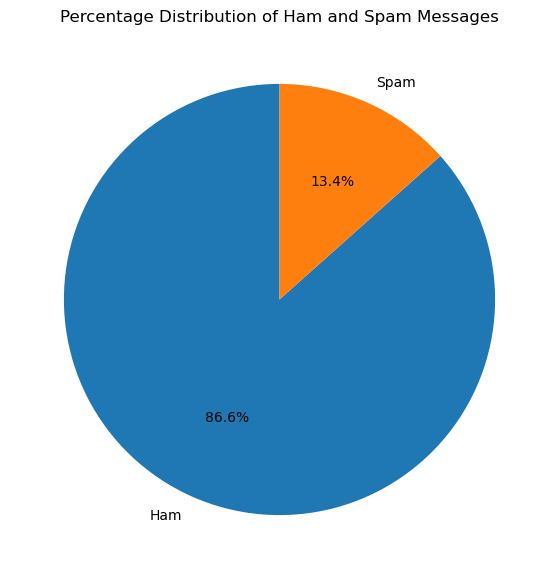

In [28]:
labels = ["Ham", "Spam"]
sizes = [
    class_counts.get(0, 0),
    class_counts.get(1, 0)
]

plt.figure(figsize=(7, 7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Ham and Spam Messages")

plt.show()

In [ ]:
## Text Preprocessing

Raw messages contain uppercase characters, punctuation, numbers, URLs and common words that may not contribute significantly to classification.

The preprocessing pipeline includes:

1. Convert text to lowercase.
2. Remove URLs.
3. Remove punctuation.
4. Remove numbers.
5. Tokenize text.
6. Remove stopwords.
7. Lemmatize words.

This produces cleaner textual data for feature extraction.

In [30]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Tokenization
    words = text.split()
    
    # Stopword removal and lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [32]:
df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back id like fun...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile month u r entitled update latest colour...


In [33]:
for i in range(5):
    print("Original:")
    print(df.loc[i, "message"])
    
    print("\nCleaned:")
    print(df.loc[i, "clean_message"])
    
    print("-" * 80)

Original:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned:
go jurong point crazy available bugis n great world la e buffet cine got amore wat
--------------------------------------------------------------------------------
Original:
Ok lar... Joking wif u oni...

Cleaned:
ok lar joking wif u oni
--------------------------------------------------------------------------------
Original:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Cleaned:
free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over
--------------------------------------------------------------------------------
Original:
U dun say so early hor... U c already then say...

Cleaned:
u dun say early hor u c already say
-------------------------------------------------------------------------------

In [ ]:
## TF-IDF Feature Extraction

TF-IDF stands for **Term Frequency-Inverse Document Frequency**.

It converts text into numerical feature vectors that machine learning algorithms can process.

### Term Frequency (TF)

TF measures how frequently a word occurs in a particular document.

### Inverse Document Frequency (IDF)

IDF reduces the importance of words that occur frequently across many documents.

### TF-IDF

The combination of TF and IDF gives greater importance to words that are more informative for distinguishing between classes.

In this project, TF-IDF is used to transform cleaned messages into numerical vectors before training the classifiers.

In [66]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Make sure the required columns exist
assert "message" in df.columns, "Column 'message' not found in dataframe."
assert "label" in df.columns, "Column 'label' not found in dataframe."

# Ensure text and labels are in the correct format
texts = df["message"].astype(str)
labels = df["label"].astype(str).str.lower().str.strip()

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

# Convert text into numerical features
X = tfidf.fit_transform(texts)

# Target variable
y = labels

print("TF-IDF feature extraction completed successfully!")
print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature matrix type:", type(X))

TF-IDF feature extraction completed successfully!
Number of samples : 5572
Number of features: 5000
Feature matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [67]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset split completed successfully!")
print("-" * 45)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")
print(f"Training features: {X_train.shape[1]}")
print(f"Testing features : {X_test.shape[1]}")

Dataset split completed successfully!
---------------------------------------------
Training samples: 4457
Testing samples : 1115
Training features: 5000
Testing features : 5000


In [72]:
# Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

print("Multinomial Naive Bayes trained successfully!")
print("Predictions generated:", len(y_pred_nb))

Multinomial Naive Bayes trained successfully!
Predictions generated: 1115


In [74]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")
print("Predictions generated:", len(y_pred_lr))

Logistic Regression trained successfully!
Predictions generated: 1115


In [78]:
# Linear Support Vector Machine

from sklearn.svm import LinearSVC

# Create SVM model
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

# Train model
svm_model.fit(X_train, y_train)

# Generate predictions
y_pred_svm = svm_model.predict(X_test)

print("Linear SVM trained successfully!")
print("Predictions generated:", len(y_pred_svm))

Linear SVM trained successfully!
Predictions generated: 1115


In [79]:
# Evaluate All Models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def calculate_metrics(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        pos_label="spam",
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }


# Calculate metrics
nb_results = calculate_metrics(
    "Multinomial Naive Bayes",
    y_test,
    y_pred_nb
)

lr_results = calculate_metrics(
    "Logistic Regression",
    y_test,
    y_pred_lr
)

svm_results = calculate_metrics(
    "Linear SVM",
    y_test,
    y_pred_svm
)

# Create comparison dataframe
results = pd.DataFrame([
    nb_results,
    lr_results,
    svm_results
])

print("Model comparison completed!")

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

Model comparison completed!


,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9731,0.9917,0.8054,0.8889
1,Logistic Regression,0.9650,1.0000,0.7383,0.8494
2,Linear SVM,0.9821,0.9924,0.8725,0.9286


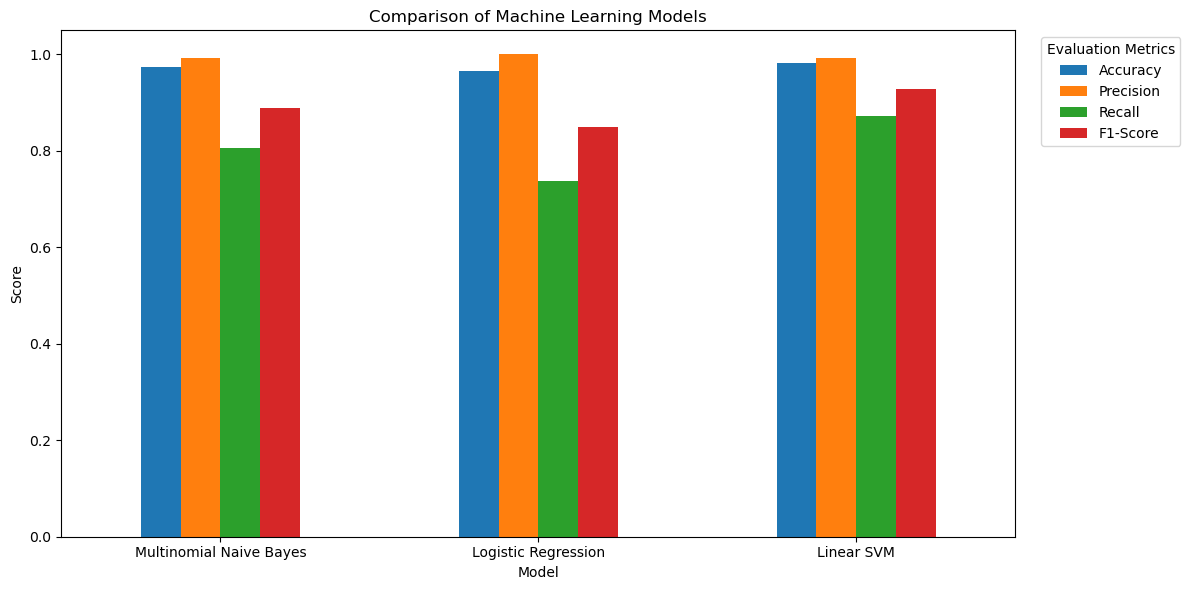

In [80]:
# Compare Model Performance

import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

ax = results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(
    title="Evaluation Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

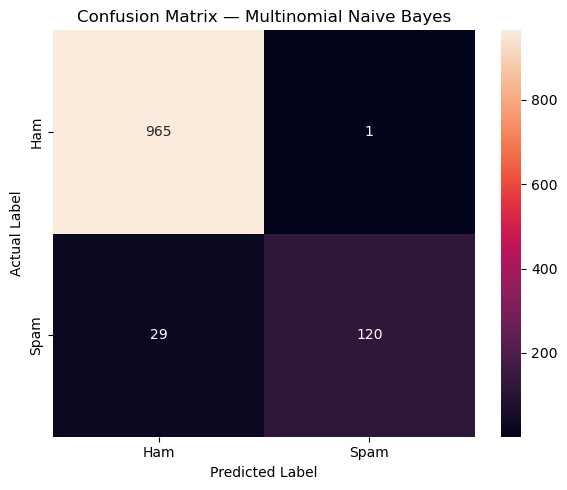

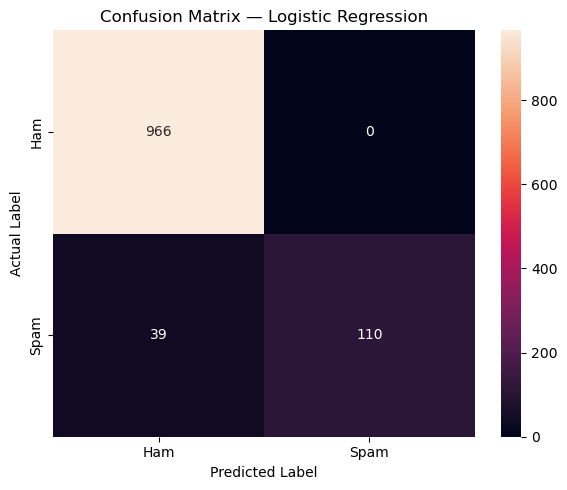

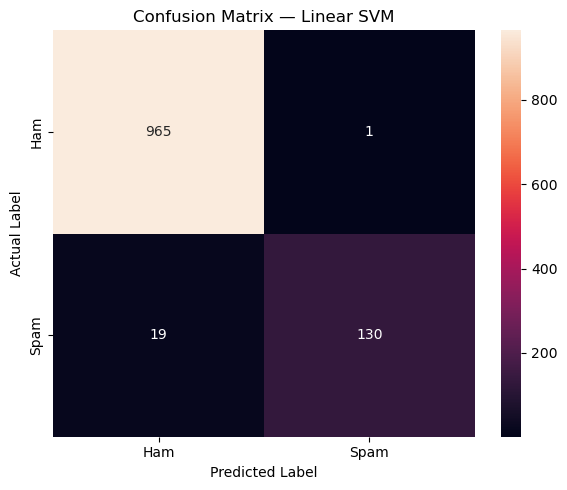

In [82]:
# Confusion Matrices

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_predictions = {
    "Multinomial Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["ham", "spam"]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

In [83]:
# Detailed Classification Reports

model_predictions = {
    "Multinomial Naive Bayes": y_pred_nb,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm
}

for model_name, predictions in model_predictions.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            labels=["ham", "spam"],
            zero_division=0
        )
    )


Multinomial Naive Bayes
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115


Logistic Regression
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115


Linear SVM
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg    

In [85]:
# Custom SMS Spam Detection

def predict_sms(message):
    # Convert message into TF-IDF features
    message_tfidf = tfidf.transform([message])

    # Predictions from all three models
    nb_prediction = nb_model.predict(message_tfidf)[0]
    lr_prediction = lr_model.predict(message_tfidf)[0]
    svm_prediction = svm_model.predict(message_tfidf)[0]

    return nb_prediction, lr_prediction, svm_prediction


# Test messages
test_messages = [
    "Congratulations! You have won a free prize. Call now to claim your reward!",
    "Hey, are we still meeting for lunch today?",
    "URGENT! You have been selected for a cash reward. Reply now!",
    "Can you send me the assignment when you get home?"
]

for message in test_messages:

    nb_pred, lr_pred, svm_pred = predict_sms(message)

    print("\n" + "=" * 70)
    print("Message:", message)
    print("-" * 70)
    print("Naive Bayes      :", nb_pred.upper())
    print("Logistic Regression:", lr_pred.upper())
    print("Linear SVM       :", svm_pred.upper())


Message: Congratulations! You have won a free prize. Call now to claim your reward!
----------------------------------------------------------------------
Naive Bayes      : SPAM
Logistic Regression: SPAM
Linear SVM       : SPAM

Message: Hey, are we still meeting for lunch today?
----------------------------------------------------------------------
Naive Bayes      : HAM
Logistic Regression: HAM
Linear SVM       : HAM

Message: URGENT! You have been selected for a cash reward. Reply now!
----------------------------------------------------------------------
Naive Bayes      : SPAM
Logistic Regression: SPAM
Linear SVM       : SPAM

Message: Can you send me the assignment when you get home?
----------------------------------------------------------------------
Naive Bayes      : HAM
Logistic Regression: HAM
Linear SVM       : HAM


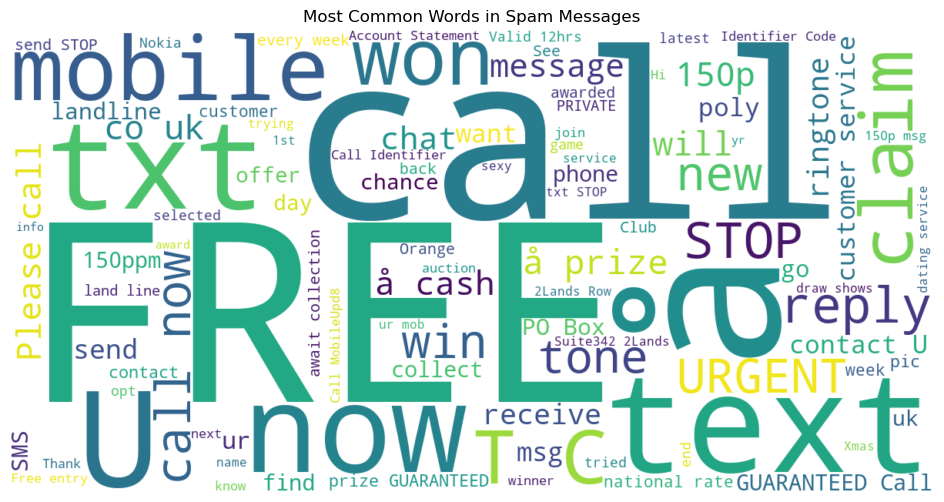

In [86]:
# WordCloud for Spam Messages

from wordcloud import WordCloud

spam_text = " ".join(
    df.loc[df["label"] == "spam", "message"].astype(str)
)

spam_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.show()

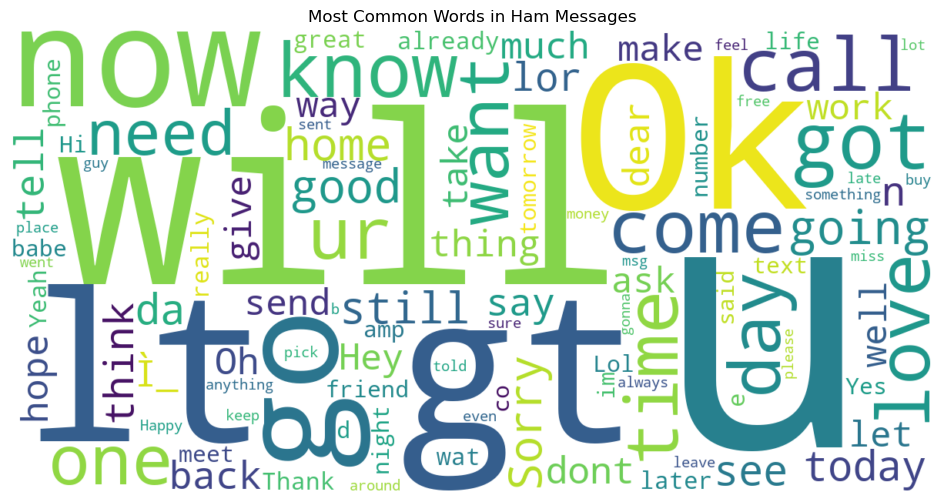

In [87]:
# WordCloud for Ham Messages

ham_text = " ".join(
    df.loc[df["label"] == "ham", "message"].astype(str)
)

ham_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(ham_text)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Ham Messages")
plt.show()

In [84]:
# Select Best Model

best_model_row = results.loc[
    results["F1-Score"].idxmax()
]

print("BEST PERFORMING MODEL")
print("=" * 50)

print("Model     :", best_model_row["Model"])
print("Accuracy  :", f"{best_model_row['Accuracy']:.4f}")
print("Precision :", f"{best_model_row['Precision']:.4f}")
print("Recall    :", f"{best_model_row['Recall']:.4f}")
print("F1-Score  :", f"{best_model_row['F1-Score']:.4f}")

BEST PERFORMING MODEL
Model     : Linear SVM
Accuracy  : 0.9821
Precision : 0.9924
Recall    : 0.8725
F1-Score  : 0.9286


In [88]:
# Interactive SMS Spam Detector

def detect_spam(message):

    message_tfidf = tfidf.transform([message])

    predictions = {
        "Naive Bayes": nb_model.predict(message_tfidf)[0],
        "Logistic Regression": lr_model.predict(message_tfidf)[0],
        "Linear SVM": svm_model.predict(message_tfidf)[0]
    }

    return predictions


user_message = input("Enter an SMS message: ")

predictions = detect_spam(user_message)

print("\nModel Predictions")
print("=" * 50)

for model, prediction in predictions.items():
    print(f"{model:<25}: {prediction.upper()}")

Enter an SMS message:  Congratulations! You won a free prize!



Model Predictions
Naive Bayes              : SPAM
Logistic Regression      : SPAM
Linear SVM               : SPAM


In [ ]:
# Conclusion

This project developed an SMS Spam Detection system using Natural Language
Processing and machine learning techniques.

The SMS Spam Collection dataset was cleaned and prepared before converting
the textual messages into numerical representations using TF-IDF.

Three machine learning algorithms were implemented:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine (SVM)

The models were evaluated using Accuracy, Precision, Recall, and F1-Score.
Confusion matrices and performance comparison graphs were also generated.

The model with the highest F1-Score was selected as the best-performing model.
F1-Score was considered important because the dataset contains considerably
more legitimate messages than spam messages.

The final system can classify new SMS messages as either Ham or Spam and
demonstrates the application of Natural Language Processing and supervised
machine learning for automated spam detection.